In [20]:
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings('ignore')

DATA_DIR  = '/kaggle/input/competitions/datathon-2026-round-1/'
TRAIN_FILE = DATA_DIR + 'sales.csv'
TEST_FILE  = DATA_DIR + 'sample_submission.csv' # Đổi tên biến cho chuẩn ngữ nghĩa

# Hàm tạo features chung để dùng cho cả Train và Test
def create_time_features(df):
    # Trích xuất các thuộc tính thời gian cơ bản
    df['day_of_year'] = df['Date'].dt.dayofyear
    
    # Lấy ngày trong tuần dạng số (0: Monday -> 6: Sunday) để mô hình dễ đọc hơn
    df['day_of_week_num'] = df['Date'].dt.dayofweek 
    
    # Xử lý năm nhuận linh hoạt thay vì fix cứng 365
    days_in_year = df['Date'].dt.is_leap_year.map({True: 366, False: 365})
    
    # Cyclical encoding cho day_of_year
    df['day_of_year_sin'] = np.sin(2 * np.pi * df['day_of_year'] / days_in_year)
    df['day_of_year_cos'] = np.cos(2 * np.pi * df['day_of_year'] / days_in_year)
    
    # Gợi ý: Có thể làm Cyclical encoding cho cả day_of_week (chu kỳ 7 ngày)
    df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week_num'] / 7)
    df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week_num'] / 7)
    
    return df

# Load data
train = pd.read_csv(TRAIN_FILE, parse_dates=['Date'])
test  = pd.read_csv(TEST_FILE, parse_dates=['Date'])

# Apply feature engineering
train = create_time_features(train)
test  = create_time_features(test)

In [21]:
train.head()

,Date,Revenue,COGS,day_of_year,day_of_week_num,day_of_year_sin,day_of_year_cos,day_of_week_sin,day_of_week_cos
0,2012-07-04,5123547.94,3982991.19,186,2,-0.051479,-0.998674,0.974928,-0.222521
1,2012-07-05,2751773.45,2150580.23,187,3,-0.068615,-0.997643,0.433884,-0.900969
2,2012-07-06,3054029.42,2517632.84,188,4,-0.085731,-0.996318,-0.433884,-0.900969
3,2012-07-07,2667930.94,2108246.62,189,5,-0.102821,-0.994700,-0.974928,-0.222521
4,2012-07-08,2360851.90,1808622.79,190,6,-0.119881,-0.992788,-0.781831,0.623490


In [22]:
print(train.dtypes)
print(train.describe())
print(train.isna().sum())

Date               datetime64[ns]
Revenue                   float64
COGS                      float64
day_of_year                 int32
day_of_week_num             int32
day_of_year_sin           float64
day_of_year_cos           float64
day_of_week_sin           float64
day_of_week_cos           float64
dtype: object
                      Date       Revenue          COGS  day_of_year  \
count                 3833  3.833000e+03  3.833000e+03  3833.000000   
mean   2017-10-02 00:00:00  4.286584e+06  3.695134e+06   187.487086   
min    2012-07-04 00:00:00  2.798139e+05  2.365763e+05     1.000000   
25%    2015-02-17 00:00:00  2.471089e+06  2.150580e+06    96.000000   
50%    2017-10-02 00:00:00  3.647304e+06  3.161113e+06   192.000000   
75%    2020-05-17 00:00:00  5.350877e+06  4.637294e+06   279.000000   
max    2022-12-31 00:00:00  2.090527e+07  1.653586e+07   366.000000   
std                    NaN  2.624840e+06  2.219789e+06   105.401736   

       day_of_week_num  day_of_year_sin 

<Axes: xlabel='day_of_week_num', ylabel='Revenue'>

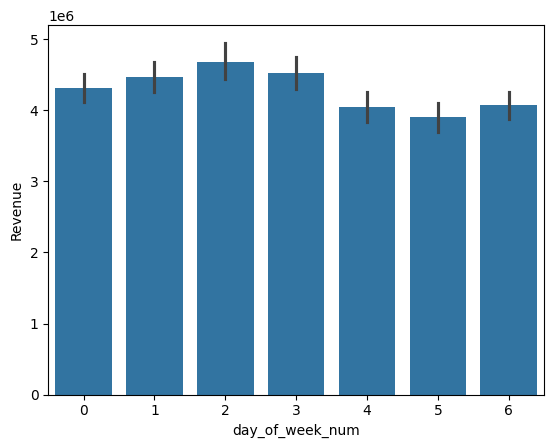

In [23]:
import seaborn as sns

sns.barplot(x='day_of_week_num', y='Revenue', data=train)

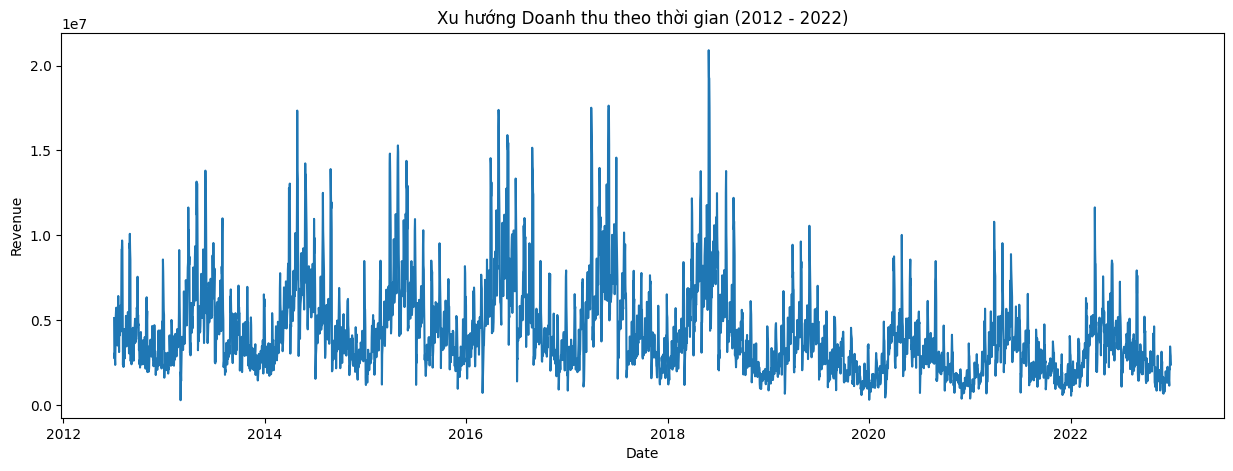

In [24]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 5))
sns.lineplot(x='Date', y='Revenue', data=train)
plt.title('Xu hướng Doanh thu theo thời gian (2012 - 2022)')
plt.show()

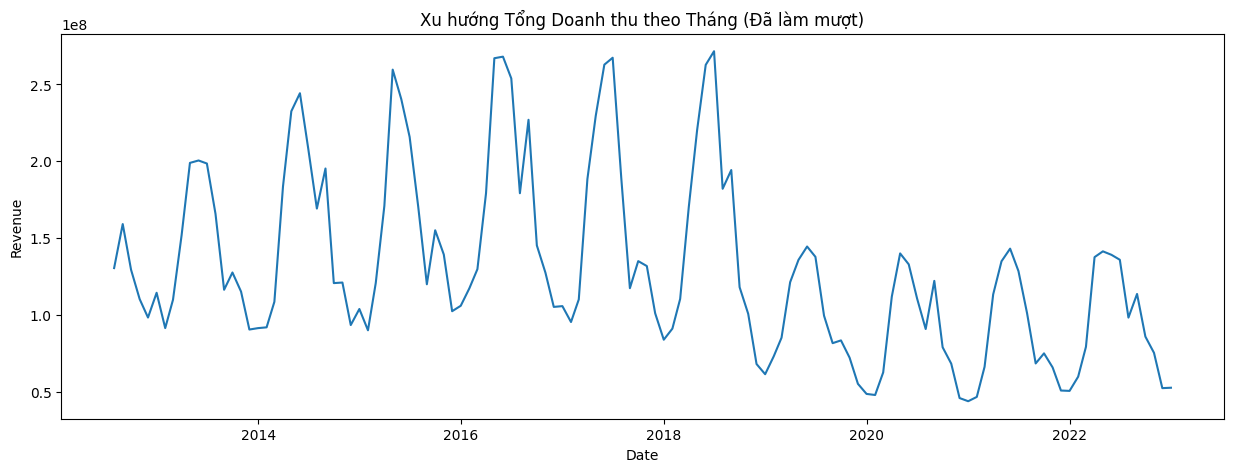

In [26]:
plt.figure(figsize=(15, 5))
# Gộp theo tháng ('M') và tính tổng doanh thu
monthly_revenue = train.set_index('Date')['Revenue'].resample('ME').sum()
sns.lineplot(data=monthly_revenue)
plt.title('Xu hướng Tổng Doanh thu theo Tháng (Đã làm mượt)')
plt.show()

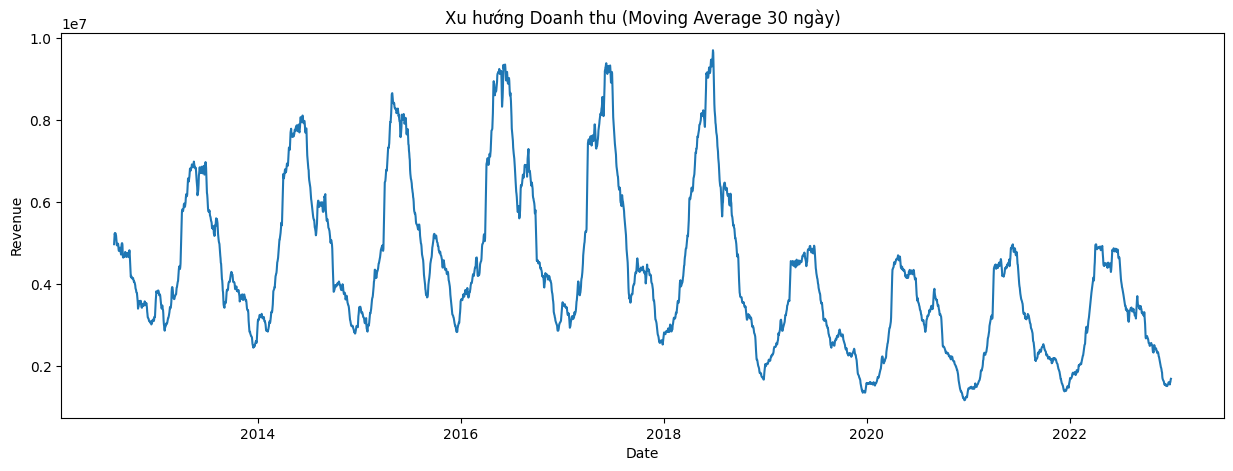

In [27]:
plt.figure(figsize=(15, 5))
# Trung bình của 30 ngày gần nhất
sns.lineplot(x=train['Date'], y=train['Revenue'].rolling(30).mean())
plt.title('Xu hướng Doanh thu (Moving Average 30 ngày)')
plt.show()

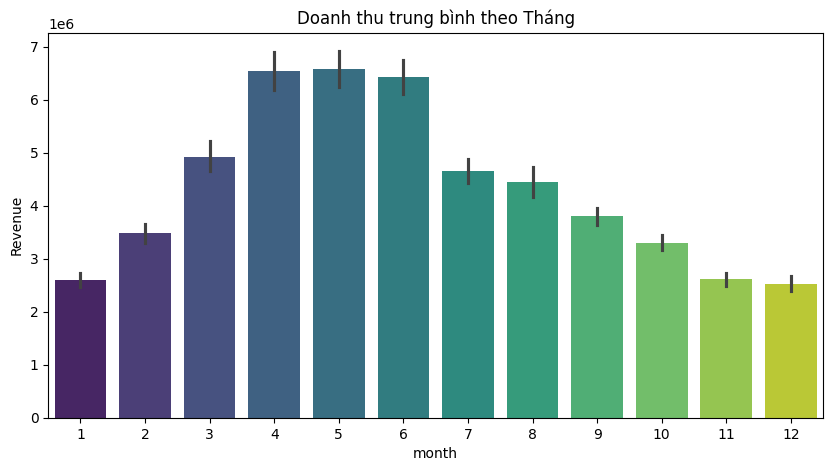

In [28]:
train['month'] = train['Date'].dt.month
plt.figure(figsize=(10, 5))
sns.barplot(x='month', y='Revenue', data=train, palette='viridis')
plt.title('Doanh thu trung bình theo Tháng')
plt.show()

In [29]:
# Biến đổi tháng thành tọa độ vòng tròn (chu kỳ 12 tháng)
train['month_sin'] = np.sin(2 * np.pi * train['month'] / 12)
train['month_cos'] = np.cos(2 * np.pi * train['month'] / 12)

In [30]:
train.head()

,Date,Revenue,COGS,day_of_year,day_of_week_num,day_of_year_sin,day_of_year_cos,day_of_week_sin,day_of_week_cos,month,month_sin,month_cos
0,2012-07-04,5123547.94,3982991.19,186,2,-0.051479,-0.998674,0.974928,-0.222521,7,-0.5,-0.866025
1,2012-07-05,2751773.45,2150580.23,187,3,-0.068615,-0.997643,0.433884,-0.900969,7,-0.5,-0.866025
2,2012-07-06,3054029.42,2517632.84,188,4,-0.085731,-0.996318,-0.433884,-0.900969,7,-0.5,-0.866025
3,2012-07-07,2667930.94,2108246.62,189,5,-0.102821,-0.994700,-0.974928,-0.222521,7,-0.5,-0.866025
4,2012-07-08,2360851.90,1808622.79,190,6,-0.119881,-0.992788,-0.781831,0.623490,7,-0.5,-0.866025


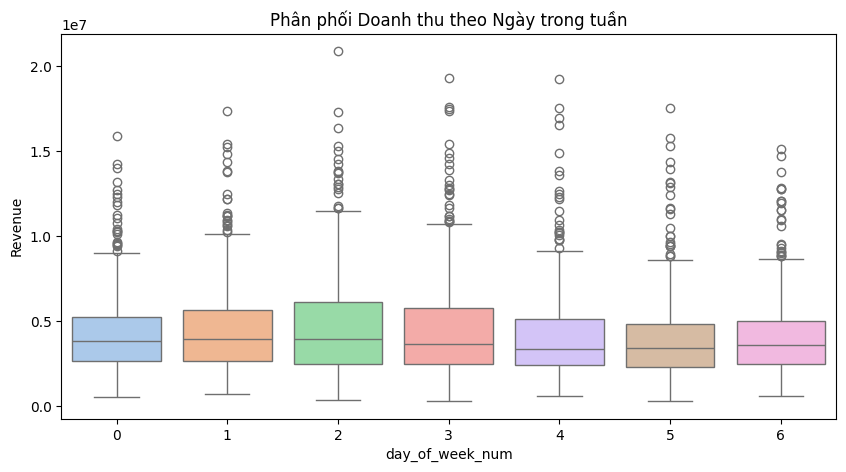

In [31]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='day_of_week_num', y='Revenue', data=train, palette='pastel')
plt.title('Phân phối Doanh thu theo Ngày trong tuần')
plt.show()

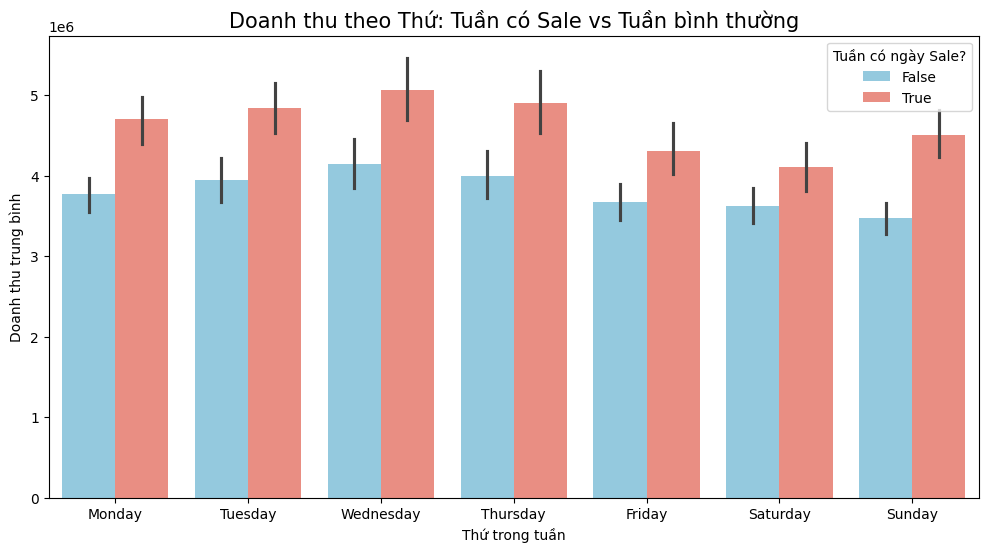

In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. TẠO TÍNH NĂNG VỚI VECTORIZATION
is_double_day = train['Date'].dt.day == train['Date'].dt.month
is_payday = train['Date'].dt.day >= 25

train['is_sale_day'] = is_double_day | is_payday

# 2. XÁC ĐỊNH TUẦN SALE
train['year_week'] = train['Date'].dt.strftime('%Y-%U')
weeks_with_sale = train.groupby('year_week')['is_sale_day'].any()
train['is_sale_week'] = train['year_week'].map(weeks_with_sale)

# ---- SỬA LỖI Ở ĐÂY: Tạo lại cột tên thứ bằng chữ để vẽ biểu đồ cho đẹp ----
train['day_of_week_name'] = train['Date'].dt.day_name()
# ---------------------------------------------------------------------------

# 3. VẼ BIỂU ĐỒ
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(12, 6))
sns.barplot(
    data=train, 
    x='day_of_week_name', # Dùng đúng tên cột vừa tạo
    y='Revenue', 
    hue='is_sale_week', 
    order=day_order,
    palette={True: 'salmon', False: 'skyblue'}
)

plt.title('Doanh thu theo Thứ: Tuần có Sale vs Tuần bình thường', fontsize=15)
plt.ylabel('Doanh thu trung bình')
plt.xlabel('Thứ trong tuần')
plt.legend(title='Tuần có ngày Sale?')
plt.show()

# (Tùy chọn) Xóa cột chữ đi nếu không cần dùng đưa vào mô hình học máy
# train = train.drop(columns=['day_of_week_name'])

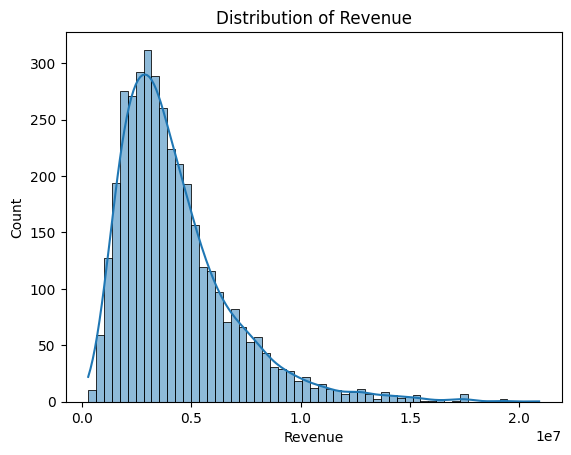

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(train['Revenue'], kde=True)
plt.title('Distribution of Revenue')
plt.show()

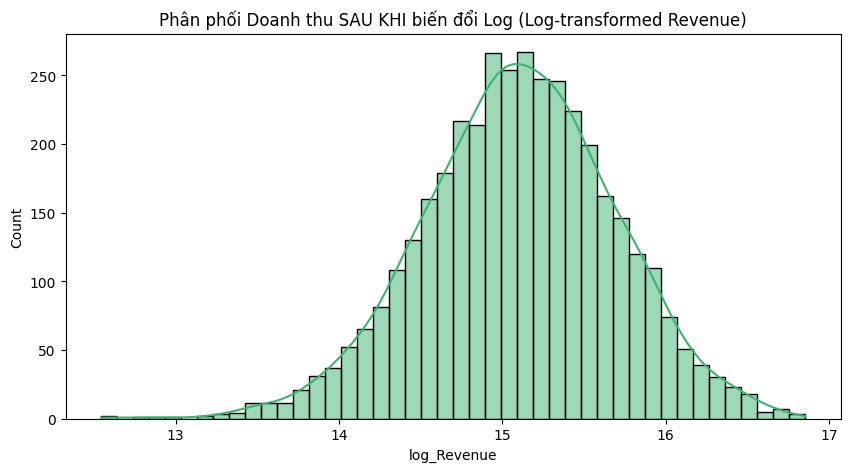

In [35]:
import numpy as np

# Sử dụng log1p (log(1 + x)) để xử lý an toàn kể cả khi có giá trị 0
train['log_Revenue'] = np.log1p(train['Revenue'])

plt.figure(figsize=(10, 5))
sns.histplot(train['log_Revenue'], kde=True, color='mediumseagreen')
plt.title('Phân phối Doanh thu SAU KHI biến đổi Log (Log-transformed Revenue)')
plt.show()

# Test another feauture engineering

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor,plot_importance
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import math
import warnings

warnings.filterwarnings("ignore")

In [42]:
DATA_DIR = "/kaggle/input/competitions/datathon-2026-round-1/"

sales = pd.read_csv(DATA_DIR + "sales.csv", parse_dates=["Date"])
test = pd.read_csv(DATA_DIR + "sample_submission.csv", parse_dates=["Date"])
promotions = pd.read_csv(DATA_DIR + "promotions.csv", parse_dates=["start_date", "end_date"])

print(f"Train Shape: {sales.shape} | Test Shape: {test.shape} | Promos Shape: {promotions.shape}")

Train Shape: (3833, 3) | Test Shape: (548, 3) | Promos Shape: (50, 10)


In [43]:
print("--- DATE BOUNDARIES ---")
print(f"Train Period: {sales['Date'].min().date()} to {sales['Date'].max().date()}")
print(f"Test Period : {test['Date'].min().date()} to {test['Date'].max().date()}")

print("\n--- BASELINE REVENUE STATS ---")
print(sales[["Revenue", "COGS"]].describe().round(2))

--- DATE BOUNDARIES ---
Train Period: 2012-07-04 to 2022-12-31
Test Period : 2023-01-01 to 2024-07-01

--- BASELINE REVENUE STATS ---
           Revenue         COGS
count      3833.00      3833.00
mean    4286584.03   3695134.49
std     2624840.20   2219788.77
min      279813.94    236576.31
25%     2471088.82   2150580.23
50%     3647303.90   3161112.99
75%     5350877.20   4637293.92
max    20905271.35  16535857.67


In [44]:
train = sales.copy()
train["is_test"] = 0
test_df = test[["Date"]].copy()
test_df["is_test"] = 1
df = pd.concat([train, test_df], ignore_index=True)

# 1. Calendar Features
df["day_of_week"] = df["Date"].dt.dayofweek
df["day_of_month"] = df["Date"].dt.day
df["day_of_year"] = df["Date"].dt.dayofyear
df["month"] = df["Date"].dt.month
df["year"] = df["Date"].dt.year
df["is_weekend"] = np.where(df["day_of_week"] >= 5, 1, 0)
df["is_payday_window"] = np.where((df["day_of_month"] >= 25) | (df["day_of_month"] <= 5), 1, 0)
df["is_double_day"] = np.where(df["month"] == df["day_of_month"], 1, 0)
df["days_since_start"] = (df["Date"] - df["Date"].min()).dt.days
tet_dates = {
    2012: "2012-01-23",
    2013: "2013-02-10",
    2014: "2014-01-31",
    2015: "2015-02-19",
    2016: "2016-02-08",
    2017: "2017-01-28",
    2018: "2018-02-16",
    2019: "2019-02-05",
    2020: "2020-01-25",
    2021: "2021-02-12",
    2022: "2022-02-01",
    2023: "2023-01-22",
    2024: "2024-02-10",
}
tet_map = pd.DataFrame(list(tet_dates.items()), columns=["year", "tet_date"])
tet_map["tet_date"] = pd.to_datetime(tet_map["tet_date"])

df = df.merge(tet_map, on="year", how="left")
df["days_to_tet"] = (df["tet_date"] - df["Date"]).dt.days
df["is_pre_tet_rush"] = np.where((df["days_to_tet"] > 0) & (df["days_to_tet"] <= 21), 1, 0)
df["is_tet_holiday"] = np.where((df["days_to_tet"] <= 0) & (df["days_to_tet"] >= -6), 1, 0)

promo_range = pd.date_range(start=df["Date"].min(), end=df["Date"].max())
daily_p = pd.DataFrame({"Date": promo_range, "is_promo": 0, "max_disc": 0.0})
for _, row in promotions.iterrows():
    mask = (daily_p["Date"] >= row["start_date"]) & (daily_p["Date"] <= row["end_date"])
    daily_p.loc[mask, "is_promo"] = 1
    if row["promo_type"] == "percentage":
        daily_p.loc[mask, "max_disc"] = np.maximum(
            daily_p.loc[mask, "max_disc"], row["discount_value"]
        )

df = df.merge(daily_p, on="Date", how="left").fillna(0)


In [46]:
df.head()

,Date,Revenue,COGS,is_test,day_of_week,day_of_month,day_of_year,month,year,is_weekend,is_payday_window,is_double_day,days_since_start,tet_date,days_to_tet,is_pre_tet_rush,is_tet_holiday,is_promo,max_disc
0,2012-07-04,5123547.94,3982991.19,0,2,4,186,7,2012,0,1,0,0,2012-01-23,-163,0,0,0,0.0
1,2012-07-05,2751773.45,2150580.23,0,3,5,187,7,2012,0,1,0,1,2012-01-23,-164,0,0,0,0.0
2,2012-07-06,3054029.42,2517632.84,0,4,6,188,7,2012,0,0,0,2,2012-01-23,-165,0,0,0,0.0
3,2012-07-07,2667930.94,2108246.62,0,5,7,189,7,2012,1,0,1,3,2012-01-23,-166,0,0,0,0.0
4,2012-07-08,2360851.90,1808622.79,0,6,8,190,7,2012,1,0,0,4,2012-01-23,-167,0,0,0,0.0


2026-04-24 13:59:45.629732: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777039186.032150      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777039186.149302      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777039187.088994      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777039187.089044      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777039187.089047      55 computation_placer.cc:177] computation placer alr

🚀 Đang huấn luyện CNN 1D...


I0000 00:00:1777039227.369072     106 service.cc:152] XLA service 0x78713000aee0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777039227.369120     106 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777039227.369123     106 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777039227.795629     106 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1777039231.105688     106 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step


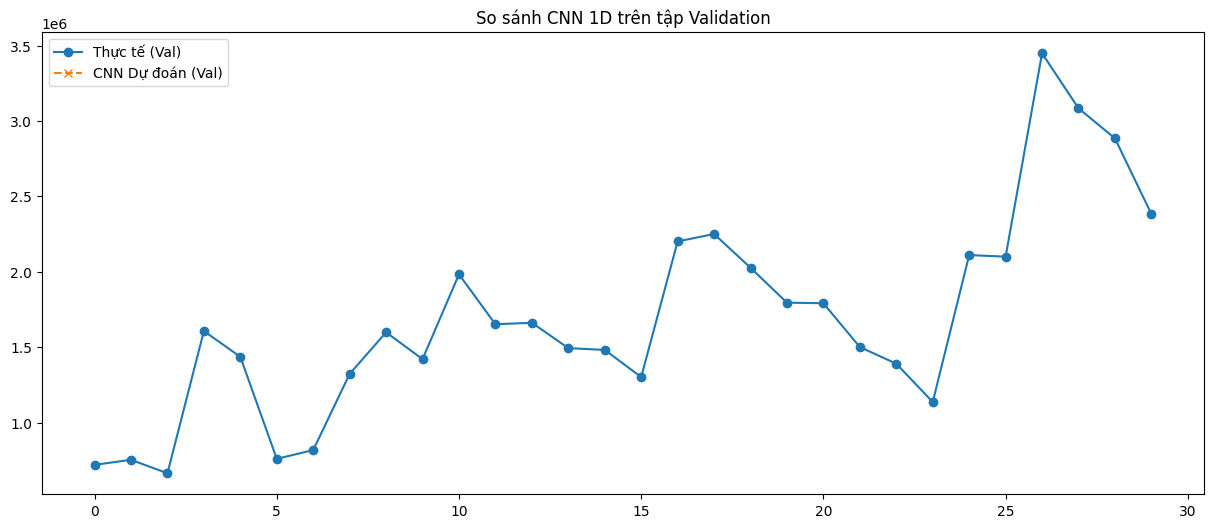

✅ Hoàn tất! File: submission_cnn.csv


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import warnings

warnings.filterwarnings("ignore")

# ==========================================
# 1. ĐỌC VÀ GHÉP DỮ LIỆU
# ==========================================
DATA_DIR = "/kaggle/input/competitions/datathon-2026-round-1/"
sales = pd.read_csv(DATA_DIR + "sales.csv", parse_dates=["Date"])
test = pd.read_csv(DATA_DIR + "sample_submission.csv", parse_dates=["Date"])
promotions = pd.read_csv(DATA_DIR + "promotions.csv", parse_dates=["start_date", "end_date"])

avg_cogs_ratio = (sales['COGS'] / sales['Revenue']).mean()

train = sales.copy()
train["is_test"] = 0
test_df = test[["Date"]].copy()
test_df["is_test"] = 1
df = pd.concat([train, test_df], ignore_index=True).sort_values("Date")

# ==========================================
# 2. FEATURE ENGINEERING (Giống bản trước)
# ==========================================
df["day_of_week"] = df["Date"].dt.dayofweek
df["day_of_month"] = df["Date"].dt.day
df["month"] = df["Date"].dt.month
df["year"] = df["Date"].dt.year
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
df["is_payday"] = ((df["day_of_month"] >= 25) | (df["day_of_month"] <= 5)).astype(int)

tet_dates = {2012:"2012-01-23", 2013:"2013-02-10", 2014:"2014-01-31", 2015:"2015-02-19",
             2016:"2016-02-08", 2017:"2017-01-28", 2018:"2018-02-16", 2019:"2019-02-05",
             2020:"2020-01-25", 2021:"2021-02-12", 2022:"2022-02-01", 2023:"2023-01-22",
             2024:"2024-02-10", 2025:"2025-01-29", 2026:"2026-02-17"}
df["tet_date"] = pd.to_datetime(df["year"].map(tet_dates))
df["days_to_tet"] = (df["tet_date"] - df["Date"]).dt.days
df["is_pre_tet"] = ((df["days_to_tet"] > 0) & (df["days_to_tet"] <= 21)).astype(int)

# Khuyến mãi
promo_range = pd.date_range(start=df["Date"].min(), end=df["Date"].max())
daily_p = pd.DataFrame({"Date": promo_range, "is_promo": 0, "max_disc": 0.0})
for _, row in promotions.iterrows():
    mask = (daily_p["Date"] >= row["start_date"]) & (daily_p["Date"] <= row["end_date"])
    daily_p.loc[mask, "is_promo"] = 1
    if row["promo_type"] == "percentage":
        daily_p.loc[mask, "max_disc"] = np.maximum(daily_p.loc[mask, "max_disc"], row["discount_value"])
df = df.merge(daily_p, on="Date", how="left").fillna(0)

# Lag Features (Dùng lag xa để phục vụ Test)
for lag in [31, 38, 45]:
    df[f"rev_lag_{lag}"] = df.groupby("is_test")["Revenue"].shift(lag)

train_final = df[df["is_test"] == 0].dropna(subset=["rev_lag_31"])
test_final = df[df["is_test"] == 1]

features = ["day_of_week", "day_of_month", "month", "year", "is_weekend", 
            "is_payday", "days_to_tet", "is_pre_tet", "is_promo", "max_disc",
            "rev_lag_31", "rev_lag_38", "rev_lag_45"]

# ==========================================
# 3. CHUẨN HÓA DỮ LIỆU (BẮT BUỘC CHO CNN)
# ==========================================
scaler_x = StandardScaler()
scaler_y = StandardScaler()

# Tách tập Train/Val
X_full = train_final[features]
y_full = train_final["Revenue"]

val_days = 30
X_train_raw = X_full.iloc[:-val_days]
y_train_raw = y_full.iloc[:-val_days]
X_val_raw = X_full.iloc[-val_days:]
y_val_raw = y_full.iloc[-val_days:]

# Fit scaler và transform
X_train_scaled = scaler_x.fit_transform(X_train_raw)
X_val_scaled = scaler_x.transform(X_val_raw)
X_test_scaled = scaler_x.transform(test_final[features])

y_train_scaled = scaler_y.fit_transform(y_train_raw.values.reshape(-1, 1))
y_val_scaled = scaler_y.transform(y_val_raw.values.reshape(-1, 1))

# RESHAPE về 3D cho CNN 1D: (Số lượng mẫu, Số đặc trưng, 1)
X_train_cnn = X_train_scaled.reshape((X_train_scaled.shape[0], X_train_scaled.shape[1], 1))
X_val_cnn = X_val_scaled.reshape((X_val_scaled.shape[0], X_val_scaled.shape[1], 1))
X_test_cnn = X_test_scaled.reshape((X_test_scaled.shape[0], X_test_scaled.shape[1], 1))

# ==========================================
# 4. XÂY DỰNG VÀ TRAIN MÔ HÌNH CNN 1D
# ==========================================
model = Sequential([
    # Lớp tích chập để tìm mối liên hệ giữa các Lag và Feature cạnh nhau
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(len(features), 1)),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),
    
    Conv1D(filters=32, kernel_size=2, activation='relu'),
    Flatten(),
    
    Dense(100, activation='relu'),
    Dropout(0.2),
    Dense(1) # Dự đoán Revenue (giá trị liên tục)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Dừng sớm nếu không cải thiện để tránh Overfit
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

print("🚀 Đang huấn luyện CNN 1D...")
history = model.fit(
    X_train_cnn, y_train_scaled,
    validation_data=(X_val_cnn, y_val_scaled),
    epochs=150,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

# ==========================================
# 5. DỰ ĐOÁN VÀ VẼ HÌNH KIỂM TRA
# ==========================================
# Dự đoán Val để check
y_val_pred_scaled = model.predict(X_val_cnn)
y_val_pred = scaler_y.inverse_transform(y_val_pred_scaled).flatten()

# Dự đoán Test
y_test_pred_scaled = model.predict(X_test_cnn)
preds_revenue = scaler_y.inverse_transform(y_test_pred_scaled).flatten()
preds_revenue = np.clip(preds_revenue, 0, None)

# Plot kết quả
plt.figure(figsize=(15, 6))
plt.plot(y_val_raw.values, label='Thực tế (Val)', marker='o')
plt.plot(y_val_pred, label='CNN Dự đoán (Val)', linestyle='--', marker='x')
plt.title("So sánh CNN 1D trên tập Validation")
plt.legend()
plt.show()

# ==========================================
# 6. XUẤT FILE SUBMISSION
# ==========================================
submission = pd.DataFrame({
    "Date": test_final["Date"].dt.strftime('%Y-%m-%d'),
    "COGS": preds_revenue * avg_cogs_ratio,
    "Revenue": preds_revenue
})

submission.to_csv("submission_cnn.csv", index=False)
print("✅ Hoàn tất! File: submission_cnn.csv")

🚀 Đang huấn luyện CNN 1D (No NaN)...
Epoch 1/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - loss: 0.7166 - val_loss: 1.0734
Epoch 2/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3741 - val_loss: 0.5023
Epoch 3/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3259 - val_loss: 0.2050
Epoch 4/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2896 - val_loss: 0.0772
Epoch 5/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2664 - val_loss: 0.0597
Epoch 6/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2581 - val_loss: 0.0895
Epoch 7/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2328 - val_loss: 0.0599
Epoch 8/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2219 - val_loss: 0.0416
Epoch 9/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2044 - val_loss: 0.0503
Epoch 10/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1889 - val_loss: 0.0848
Epoch 11/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2047 - val_loss: 0.0339
Epo

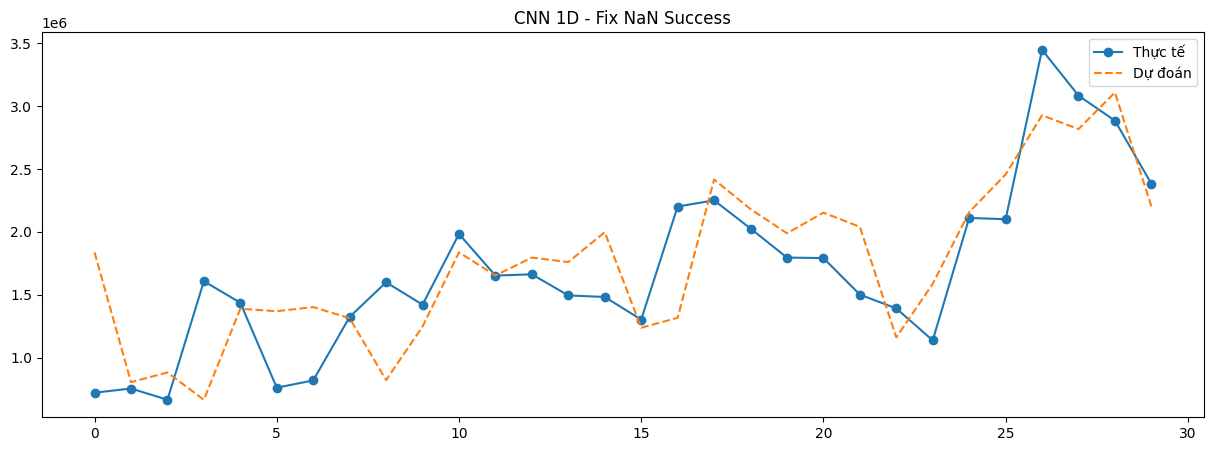

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
import warnings

warnings.filterwarnings("ignore")

# ==========================================
# 1. ĐỌC DỮ LIỆU
# ==========================================
DATA_DIR = "/kaggle/input/competitions/datathon-2026-round-1/"
sales = pd.read_csv(DATA_DIR + "sales.csv", parse_dates=["Date"])
test = pd.read_csv(DATA_DIR + "sample_submission.csv", parse_dates=["Date"])
promotions = pd.read_csv(DATA_DIR + "promotions.csv", parse_dates=["start_date", "end_date"])

avg_cogs_ratio = (sales['COGS'] / sales['Revenue']).mean()

train = sales.copy()
train["is_test"] = 0
test_df = test[["Date"]].copy()
test_df["is_test"] = 1
df = pd.concat([train, test_df], ignore_index=True).sort_values("Date")

# ==========================================
# 2. FEATURE ENGINEERING (FIXED NaN)
# ==========================================
df["day_of_week"] = df["Date"].dt.dayofweek
df["day_of_month"] = df["Date"].dt.day
df["month"] = df["Date"].dt.month
df["year"] = df["Date"].dt.year
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
df["is_payday"] = ((df["day_of_month"] >= 25) | (df["day_of_month"] <= 5)).astype(int)

tet_dates = {2012:"2012-01-23", 2013:"2013-02-10", 2014:"2014-01-31", 2015:"2015-02-19",
             2016:"2016-02-08", 2017:"2017-01-28", 2018:"2018-02-16", 2019:"2019-02-05",
             2020:"2020-01-25", 2021:"2021-02-12", 2022:"2022-02-01", 2023:"2023-01-22",
             2024:"2024-02-10", 2025:"2025-01-29", 2026:"2026-02-17"}
df["tet_date"] = pd.to_datetime(df["year"].map(tet_dates))
df["days_to_tet"] = (df["tet_date"] - df["Date"]).dt.days
df["is_pre_tet"] = ((df["days_to_tet"] > 0) & (df["days_to_tet"] <= 21)).astype(int)

# Khuyến mãi
promo_range = pd.date_range(start=df["Date"].min(), end=df["Date"].max())
daily_p = pd.DataFrame({"Date": promo_range, "is_promo": 0, "max_disc": 0.0})
for _, row in promotions.iterrows():
    mask = (daily_p["Date"] >= row["start_date"]) & (daily_p["Date"] <= row["end_date"])
    daily_p.loc[mask, "is_promo"] = 1
    if row["promo_type"] == "percentage":
        daily_p.loc[mask, "max_disc"] = np.maximum(daily_p.loc[mask, "max_disc"], row["discount_value"])
df = df.merge(daily_p, on="Date", how="left").fillna(0)

# Lag Features
features_lag = [31, 38, 45]
for lag in features_lag:
    df[f"rev_lag_{lag}"] = df.groupby("is_test")["Revenue"].shift(lag)

# --- KHẮC PHỤC LỖI NaN TẠI ĐÂY ---
features = ["day_of_week", "day_of_month", "month", "year", "is_weekend", 
            "is_payday", "days_to_tet", "is_pre_tet", "is_promo", "max_disc",
            "rev_lag_31", "rev_lag_38", "rev_lag_45"]

# Xóa TẤT CẢ các dòng có bất kỳ giá trị NaN nào trong tập train
train_final = df[df["is_test"] == 0].dropna(subset=features)
# Với tập test, nếu có NaN (thường do lag), hãy fill bằng 0 hoặc giá trị trung bình
test_final = df[df["is_test"] == 1].fillna(0)

# ==========================================
# 3. CHUẨN HÓA & TRAIN (FIXED LOSS NAN)
# ==========================================
scaler_x = StandardScaler()
scaler_y = StandardScaler()

X_full = train_final[features]
y_full = train_final["Revenue"]

val_days = 30
X_train_raw, X_val_raw = X_full.iloc[:-val_days], X_full.iloc[-val_days:]
y_train_raw, y_val_raw = y_full.iloc[:-val_days], y_full.iloc[-val_days:]

X_train_scaled = scaler_x.fit_transform(X_train_raw)
X_val_scaled = scaler_x.transform(X_val_raw)
X_test_scaled = scaler_x.transform(test_final[features])

y_train_scaled = scaler_y.fit_transform(y_train_raw.values.reshape(-1, 1))
y_val_scaled = scaler_y.transform(y_val_raw.values.reshape(-1, 1))

X_train_cnn = X_train_scaled.reshape((X_train_scaled.shape[0], X_train_scaled.shape[1], 1))
X_val_cnn = X_val_scaled.reshape((X_val_scaled.shape[0], X_val_scaled.shape[1], 1))
X_test_cnn = X_test_scaled.reshape((X_test_scaled.shape[0], X_test_scaled.shape[1], 1))

# Kiến trúc mô hình ổn định hơn
model = Sequential([
    Conv1D(filters=32, kernel_size=3, activation='relu', padding='same', input_shape=(len(features), 1)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    
    Conv1D(filters=64, kernel_size=2, activation='relu', padding='same'),
    BatchNormalization(),
    
    Flatten(),
    Dense(64, activation='relu'),
    Dense(1)
])

# Dùng optimizer Adam với kẹp gradient (gradient clipping) để chống nan
model.compile(optimizer=Adam(learning_rate=0.001, clipnorm=1.0), loss='mse')

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

print("🚀 Đang huấn luyện CNN 1D (No NaN)...")
history = model.fit(
    X_train_cnn, y_train_scaled,
    validation_data=(X_val_cnn, y_val_scaled),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# ==========================================
# 4. KẾT QUẢ
# ==========================================
y_val_pred = scaler_y.inverse_transform(model.predict(X_val_cnn)).flatten()
preds_revenue = scaler_y.inverse_transform(model.predict(X_test_cnn)).flatten().clip(0)

plt.figure(figsize=(15, 5))
plt.plot(y_val_raw.values, label='Thực tế', marker='o')
plt.plot(y_val_pred, label='Dự đoán', linestyle='--')
plt.title("CNN 1D - Fix NaN Success")
plt.legend()
plt.show()

submission = pd.DataFrame({
    "Date": test_final["Date"].dt.strftime('%Y-%m-%d'),
    "COGS": preds_revenue * avg_cogs_ratio,
    "Revenue": preds_revenue
})
submission.to_csv("submission_cnn_final.csv", index=False)

🚀 Huấn luyện CNN 1D (Không Lag Features)...
Epoch 1/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - loss: 1.0404 - val_loss: 0.7076
Epoch 2/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4189 - val_loss: 0.4173
Epoch 3/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3345 - val_loss: 0.2440
Epoch 4/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2927 - val_loss: 0.0654
Epoch 5/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2681 - val_loss: 0.0334
Epoch 6/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2527 - val_loss: 0.0439
Epoch 7/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2648 - val_loss: 0.0305
Epoch 8/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2395 - val_loss: 0.0741
Epoch 9/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2224 - val_loss: 0.0605
Epoch 10/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2515 - val_loss: 0.0316
Epoch 11/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2137 - val_loss: 0.0

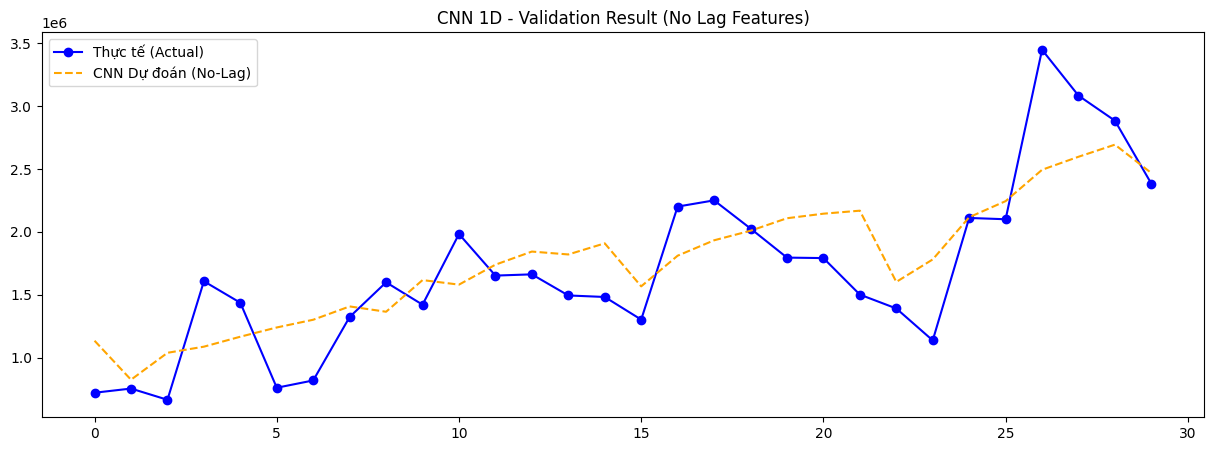

✅ FILE ĐÃ LƯU: submission_cnn_no_lag.csv


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Flatten, Dense, Dropout, BatchNormalization, MaxPooling1D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
import warnings

warnings.filterwarnings("ignore")

# ==========================================
# 1. ĐỌC DỮ LIỆU
# ==========================================
DATA_DIR = "/kaggle/input/competitions/datathon-2026-round-1/"
sales = pd.read_csv(DATA_DIR + "sales.csv", parse_dates=["Date"])
test = pd.read_csv(DATA_DIR + "sample_submission.csv", parse_dates=["Date"])
promotions = pd.read_csv(DATA_DIR + "promotions.csv", parse_dates=["start_date", "end_date"])

# Tính tỉ lệ COGS trung bình để "đối phó" với file submission
avg_cogs_ratio = (sales['COGS'] / sales['Revenue']).mean()

train = sales.copy()
train["is_test"] = 0
test_df = test[["Date"]].copy()
test_df["is_test"] = 1
df = pd.concat([train, test_df], ignore_index=True).sort_values("Date")

# ==========================================
# 2. FEATURE ENGINEERING (KHÔNG LAG)
# ==========================================
df["day_of_week"] = df["Date"].dt.dayofweek
df["day_of_month"] = df["Date"].dt.day
df["month"] = df["Date"].dt.month
df["year"] = df["Date"].dt.year
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
df["is_payday_window"] = ((df["day_of_month"] >= 25) | (df["day_of_month"] <= 5)).astype(int)

# Đặc trưng Tết
tet_dates = {2012:"2012-01-23", 2013:"2013-02-10", 2014:"2014-01-31", 2015:"2015-02-19",
             2016:"2016-02-08", 2017:"2017-01-28", 2018:"2018-02-16", 2019:"2019-02-05",
             2020:"2020-01-25", 2021:"2021-02-12", 2022:"2022-02-01", 2023:"2023-01-22",
             2024:"2024-02-10", 2025:"2025-01-29", 2026:"2026-02-17"}
df["tet_date"] = pd.to_datetime(df["year"].map(tet_dates))
df["days_to_tet"] = (df["tet_date"] - df["Date"]).dt.days
df["is_pre_tet_rush"] = ((df["days_to_tet"] > 0) & (df["days_to_tet"] <= 21)).astype(int)

# Đặc trưng Khuyến mãi
promo_range = pd.date_range(start=df["Date"].min(), end=df["Date"].max())
daily_p = pd.DataFrame({"Date": promo_range, "is_promo": 0, "max_disc": 0.0})
for _, row in promotions.iterrows():
    mask = (daily_p["Date"] >= row["start_date"]) & (daily_p["Date"] <= row["end_date"])
    daily_p.loc[mask, "is_promo"] = 1
    if row["promo_type"] == "percentage":
        daily_p.loc[mask, "max_disc"] = np.maximum(daily_p.loc[mask, "max_disc"], row["discount_value"])
df = df.merge(daily_p, on="Date", how="left").fillna(0)

# Danh sách Features mới (KHÔNG CÓ LAG)
features = ["day_of_week", "day_of_month", "month", "year", "is_weekend", 
            "is_payday_window", "days_to_tet", "is_pre_tet_rush", "is_promo", "max_disc"]

# Tách lại Train/Test
train_final = df[df["is_test"] == 0]
test_final = df[df["is_test"] == 1]

# ==========================================
# 3. PREPROCESSING & SHAPING
# ==========================================
scaler_x = StandardScaler()
scaler_y = StandardScaler()

X_full = train_final[features]
y_full = train_final["Revenue"]

val_days = 30
X_train_raw, X_val_raw = X_full.iloc[:-val_days], X_full.iloc[-val_days:]
y_train_raw, y_val_raw = y_full.iloc[:-val_days], y_full.iloc[-val_days:]

X_train_scaled = scaler_x.fit_transform(X_train_raw)
X_val_scaled = scaler_x.transform(X_val_raw)
X_test_scaled = scaler_x.transform(test_final[features])

y_train_scaled = scaler_y.fit_transform(y_train_raw.values.reshape(-1, 1))
y_val_scaled = scaler_y.transform(y_val_raw.values.reshape(-1, 1))

# Reshape cho CNN 1D: (Samples, Features, 1)
X_train_cnn = X_train_scaled.reshape((X_train_scaled.shape[0], X_train_scaled.shape[1], 1))
X_val_cnn = X_val_scaled.reshape((X_val_scaled.shape[0], X_val_scaled.shape[1], 1))
X_test_cnn = X_test_scaled.reshape((X_test_scaled.shape[0], X_test_scaled.shape[1], 1))

# ==========================================
# 4. MÔ HÌNH CNN 1D (NO-LAG VERSION)
# ==========================================
model = Sequential([
    Conv1D(filters=32, kernel_size=3, activation='relu', padding='same', input_shape=(len(features), 1)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    
    Conv1D(filters=64, kernel_size=2, activation='relu', padding='same'),
    BatchNormalization(),
    
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.1),
    Dense(1)
])

model.compile(optimizer=Adam(learning_rate=0.001, clipnorm=1.0), loss='mse')

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

print("🚀 Huấn luyện CNN 1D (Không Lag Features)...")
history = model.fit(
    X_train_cnn, y_train_scaled,
    validation_data=(X_val_cnn, y_val_scaled),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# ==========================================
# 5. DỰ ĐOÁN & XUẤT FILE
# ==========================================
# Dự đoán tập Validation để vẽ hình
y_val_pred = scaler_y.inverse_transform(model.predict(X_val_cnn)).flatten()

# Dự đoán tập Test
y_test_pred_scaled = model.predict(X_test_cnn)
preds_revenue = scaler_y.inverse_transform(y_test_pred_scaled).flatten().clip(0)

# Vẽ biểu đồ kiểm tra
plt.figure(figsize=(15, 5))
plt.plot(y_val_raw.values, label='Thực tế (Actual)', marker='o', color='blue')
plt.plot(y_val_pred, label='CNN Dự đoán (No-Lag)', linestyle='--', color='orange')
plt.title("CNN 1D - Validation Result (No Lag Features)")
plt.legend()
plt.show()

# Tạo submission
submission = pd.DataFrame({
    "Date": test_final["Date"].dt.strftime('%Y-%m-%d'),
    "COGS": preds_revenue * avg_cogs_ratio,
    "Revenue": preds_revenue
})

submission.to_csv("submission_cnn_no_lag.csv", index=False)
print("✅ FILE ĐÃ LƯU: submission_cnn_no_lag.csv")

🚀 Huấn luyện CNN 1D với Lag features...
Epoch 1/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 1.8350 - val_loss: 0.9829
Epoch 2/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4400 - val_loss: 0.7375
Epoch 3/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4065 - val_loss: 0.5759
Epoch 4/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4114 - val_loss: 0.1886
Epoch 5/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3498 - val_loss: 0.1277
Epoch 6/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3601 - val_loss: 0.0463
Epoch 7/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3128 - val_loss: 0.0375
Epoch 8/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3302 - val_loss: 0.0508
Epoch 9/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2946 - val_loss: 0.0180
Epoch 10/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3119 - val_loss: 0.0400
Epoch 11/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2828 - val_loss: 0.0296


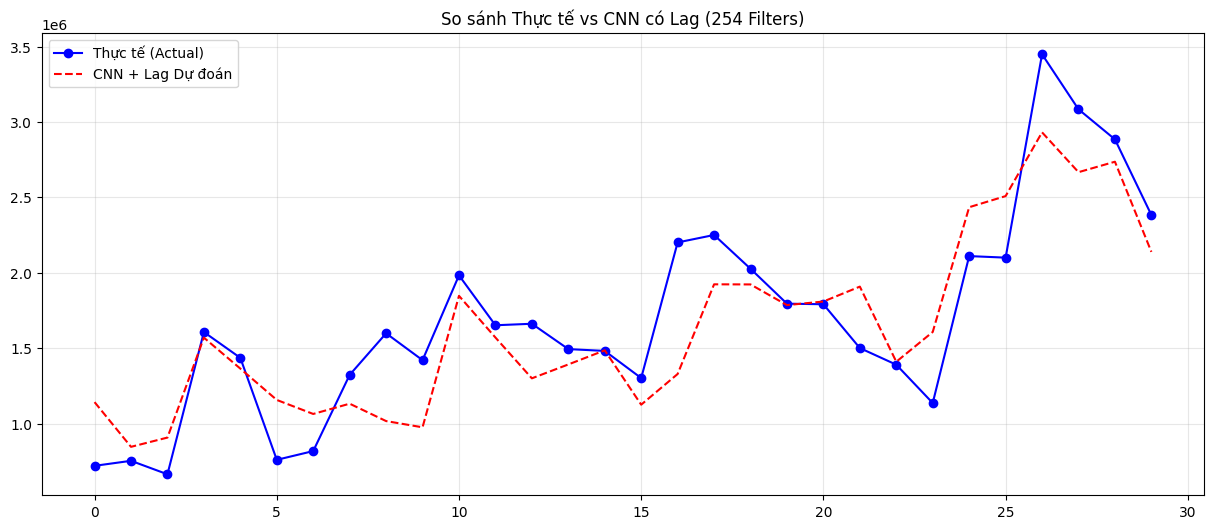

✅ File đã lưu: submission_cnn_v2.csv


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import warnings

warnings.filterwarnings("ignore")

# ==========================================
# 1. ĐỌC DỮ LIỆU
# ==========================================
DATA_DIR = "/kaggle/input/competitions/datathon-2026-round-1/"
sales = pd.read_csv(DATA_DIR + "sales.csv", parse_dates=["Date"])
test = pd.read_csv(DATA_DIR + "sample_submission.csv", parse_dates=["Date"])
promotions = pd.read_csv(DATA_DIR + "promotions.csv", parse_dates=["start_date", "end_date"])

avg_cogs_ratio = (sales['COGS'] / sales['Revenue']).mean()

train = sales.copy()
train["is_test"] = 0
test_df = test[["Date"]].copy()
test_df["is_test"] = 1
df = pd.concat([train, test_df], ignore_index=True).sort_values("Date")

# ==========================================
# 2. FEATURE ENGINEERING (CÓ LAG)
# ==========================================
# Đặc trưng thời gian cơ bản
df["day_of_week"] = df["Date"].dt.dayofweek
df["day_of_month"] = df["Date"].dt.day
df["month"] = df["Date"].dt.month
df["year"] = df["Date"].dt.year
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

# Đặc trưng Tết
tet_dates = {2012:"2012-01-23", 2013:"2013-02-10", 2014:"2014-01-31", 2015:"2015-02-19",
             2016:"2016-02-08", 2017:"2017-01-28", 2018:"2018-02-16", 2019:"2019-02-05",
             2020:"2020-01-25", 2021:"2021-02-12", 2022:"2022-02-01", 2023:"2023-01-22",
             2024:"2024-02-10", 2025:"2025-01-29", 2026:"2026-02-17"}
df["tet_date"] = pd.to_datetime(df["year"].map(tet_dates))
df["days_to_tet"] = (df["tet_date"] - df["Date"]).dt.days
df["is_pre_tet"] = ((df["days_to_tet"] > 0) & (df["days_to_tet"] <= 21)).astype(int)

# Khuyến mãi
promo_range = pd.date_range(start=df["Date"].min(), end=df["Date"].max())
daily_p = pd.DataFrame({"Date": promo_range, "is_promo": 0})
for _, row in promotions.iterrows():
    daily_p.loc[(daily_p["Date"] >= row["start_date"]) & (daily_p["Date"] <= row["end_date"]), "is_promo"] = 1
df = df.merge(daily_p, on="Date", how="left").fillna(0)

# --- THÊM LAG FEATURES (Chu kỳ tuần) ---
# Lưu ý: Với tập Test, chúng ta dùng lag >= 31 để đảm bảo có dữ liệu thực tế
lags = [31, 38, 45, 52] 
for lag in lags:
    df[f"rev_lag_{lag}"] = df.groupby("is_test")["Revenue"].shift(lag)

# Danh sách features mới bao gồm cả các cột Lag
features = ["day_of_week", "day_of_month", "month", "year", "is_weekend", 
            "days_to_tet", "is_pre_tet", "is_promo"] + [f"rev_lag_{l}" for l in lags]

# Xử lý NaN: Xóa các dòng trống ở tập train do quá trình tạo lag
train_final = df[df["is_test"] == 0].dropna(subset=features)
test_final = df[df["is_test"] == 1].fillna(0) # Tập test có thể fill 0 hoặc trung bình

# ==========================================
# 3. PREPROCESSING
# ==========================================
scaler_x = StandardScaler()
scaler_y = StandardScaler()

X_full = train_final[features]
y_full = train_final["Revenue"]

val_days = 30
X_train_raw, X_val_raw = X_full.iloc[:-val_days], X_full.iloc[-val_days:]
y_train_raw, y_val_raw = y_full.iloc[:-val_days], y_full.iloc[-val_days:]

X_train_scaled = scaler_x.fit_transform(X_train_raw)
X_val_scaled = scaler_x.transform(X_val_raw)
X_test_scaled = scaler_x.transform(test_final[features])

y_train_scaled = scaler_y.fit_transform(y_train_raw.values.reshape(-1, 1))
y_val_scaled = scaler_y.transform(y_val_raw.values.reshape(-1, 1))

X_train_cnn = X_train_scaled.reshape((X_train_scaled.shape[0], X_train_scaled.shape[1], 1))
X_val_cnn = X_val_scaled.reshape((X_val_scaled.shape[0], X_val_scaled.shape[1], 1))
X_test_cnn = X_test_scaled.reshape((X_test_scaled.shape[0], X_test_scaled.shape[1], 1))

# ==========================================
# 4. MÔ HÌNH CNN 1D (FIXED ARCHITECTURE)
# ==========================================
model = Sequential([
    Input(shape=(len(features), 1)),
    
    # Convolution layer: 254 filters, kernel size 2
    Conv1D(filters=254, kernel_size=2, activation='relu', padding='same',input_shape=(10, 1)),
    BatchNormalization(),
    
    # Max pooling layer: size 2
    MaxPooling1D(pool_size=2),
    
    # Flatten layer
    Flatten(),
    
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(1)
])

# Adam Optimizer
model.compile(optimizer=Adam(learning_rate=0.001, clipnorm=1.0), loss='mse')

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

print("🚀 Huấn luyện CNN 1D với Lag features...")
history = model.fit(
    X_train_cnn, y_train_scaled,
    validation_data=(X_val_cnn, y_val_scaled),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# ==========================================
# 5. DỰ ĐOÁN & VẼ HÌNH
# ==========================================
y_val_pred = scaler_y.inverse_transform(model.predict(X_val_cnn)).flatten()
y_test_pred = scaler_y.inverse_transform(model.predict(X_test_cnn)).flatten().clip(0)

plt.figure(figsize=(15, 6))
plt.plot(y_val_raw.values, label='Thực tế (Actual)', marker='o', color='blue')
plt.plot(y_val_pred, label='CNN + Lag Dự đoán', linestyle='--', color='red')
plt.title("So sánh Thực tế vs CNN có Lag (254 Filters)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Xuất file submission
submission = pd.DataFrame({
    "Date": test_final["Date"].dt.strftime('%Y-%m-%d'),
    "COGS": y_test_pred * avg_cogs_ratio,
    "Revenue": y_test_pred
})
submission.to_csv("submission_cnn_lag.csv", index=False)
print("✅ File đã lưu: submission_cnn_v2.csv")

🚀 Đang huấn luyện XGBoost Phiên bản nâng cấp...
[0]	validation_0-rmse:2669595.81216
[200]	validation_0-rmse:552101.42357
[400]	validation_0-rmse:355431.94816
[584]	validation_0-rmse:346911.52959


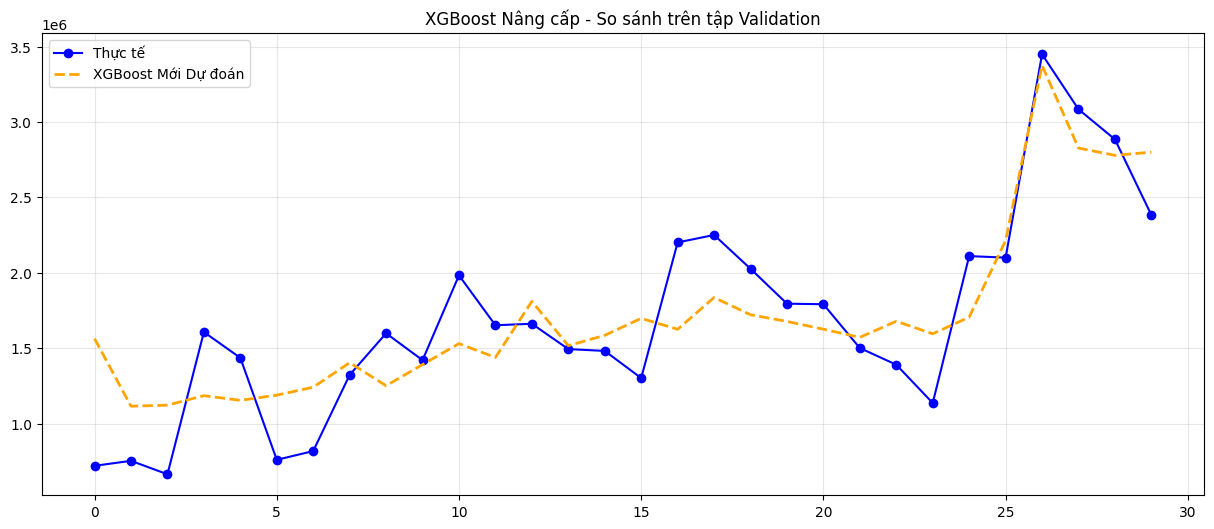

✅ File đã lưu: submission_xgb_v2.csv


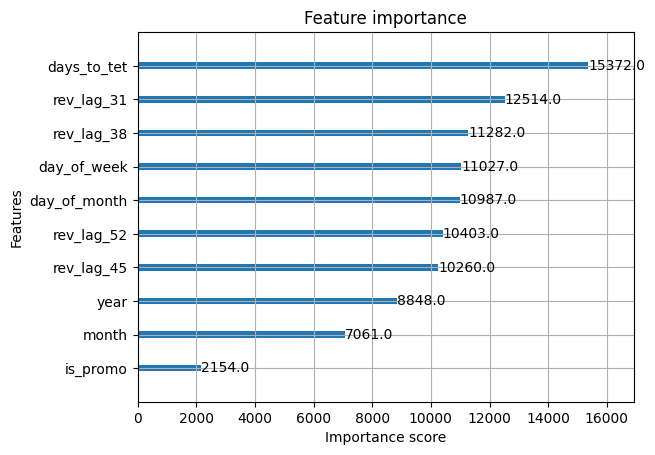

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor, plot_importance
from sklearn.metrics import mean_squared_error
import warnings

warnings.filterwarnings("ignore")

# ==========================================
# 1. ĐỌC DỮ LIỆU & GIỮ NGUYÊN FEATURE ENGINEERING
# ==========================================
DATA_DIR = "/kaggle/input/competitions/datathon-2026-round-1/"
sales = pd.read_csv(DATA_DIR + "sales.csv", parse_dates=["Date"])
test = pd.read_csv(DATA_DIR + "sample_submission.csv", parse_dates=["Date"])
promotions = pd.read_csv(DATA_DIR + "promotions.csv", parse_dates=["start_date", "end_date"])

avg_cogs_ratio = (sales['COGS'] / sales['Revenue']).mean()

train = sales.copy()
train["is_test"] = 0
test_df = test[["Date"]].copy()
test_df["is_test"] = 1
df = pd.concat([train, test_df], ignore_index=True).sort_values("Date")

# Features (Giữ nguyên bộ Lag "thần thánh")
df["day_of_week"] = df["Date"].dt.dayofweek
df["day_of_month"] = df["Date"].dt.day
df["month"] = df["Date"].dt.month
df["year"] = df["Date"].dt.year
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

# Tết & Promo
tet_dates = {2012:"2012-01-23", 2013:"2013-02-10", 2014:"2014-01-31", 2015:"2015-02-19",
             2016:"2016-02-08", 2017:"2017-01-28", 2018:"2018-02-16", 2019:"2019-02-05",
             2020:"2020-01-25", 2021:"2021-02-12", 2022:"2022-02-01", 2023:"2023-01-22",
             2024:"2024-02-10", 2025:"2025-01-29", 2026:"2026-02-17"}
df["tet_date"] = pd.to_datetime(df["year"].map(tet_dates))
df["days_to_tet"] = (df["tet_date"] - df["Date"]).dt.days
df["is_pre_tet"] = ((df["days_to_tet"] > 0) & (df["days_to_tet"] <= 21)).astype(int)

promo_range = pd.date_range(start=df["Date"].min(), end=df["Date"].max())
daily_p = pd.DataFrame({"Date": promo_range, "is_promo": 0})
for _, row in promotions.iterrows():
    daily_p.loc[(daily_p["Date"] >= row["start_date"]) & (daily_p["Date"] <= row["end_date"]), "is_promo"] = 1
df = df.merge(daily_p, on="Date", how="left").fillna(0)

# Lag Features (Duy trì bộ lag bắt chu kỳ tháng/tuần)
lags = [31, 38, 45, 52] 
for lag in lags:
    df[f"rev_lag_{lag}"] = df.groupby("is_test")["Revenue"].shift(lag)

features = ["day_of_week", "day_of_month", "month", "year", "is_weekend", 
            "days_to_tet", "is_pre_tet", "is_promo"] + [f"rev_lag_{l}" for l in lags]

train_final = df[df["is_test"] == 0].dropna(subset=features)
test_final = df[df["is_test"] == 1].fillna(0)

X_full = train_final[features]
y_full = train_final["Revenue"]

val_days = 30
X_train, X_val = X_full.iloc[:-val_days], X_full.iloc[-val_days:]
y_train, y_val = y_full.iloc[:-val_days], y_full.iloc[-val_days:]

# ==========================================
# 4. MODEL: NEW TUNED XGBOOST
# ==========================================
# Chúng ta sử dụng cấu hình mạnh hơn, thêm Regularization để tránh Overfit
new_xgb_params = {
    'n_estimators': 2000,
    'learning_rate': 0.01,         # Học chậm hơn nhưng kỹ hơn (CNN cũng dùng 0.001-0.01)
    'max_depth': 8,                # Tăng độ sâu để bắt kịp CNN ở các đỉnh cao
    'subsample': 0.8,
    'colsample_bytree': 0.7,
    'gamma': 0.1,                  # Thêm Gamma để cây "khó tính" hơn khi phân nhánh
    'reg_lambda': 1.5,             # L2 Regularization
    'reg_alpha': 0.5,              # L1 Regularization giúp loại bỏ nhiễu
    'random_state': 42,
    'objective': 'reg:squarederror',
    'early_stopping_rounds': 100
}

print("🚀 Đang huấn luyện XGBoost Phiên bản nâng cấp...")
model = XGBRegressor(**new_xgb_params)
model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=200)

# ==========================================
# 5. DỰ ĐOÁN VÀ SO SÁNH
# ==========================================
y_val_pred = model.predict(X_val)
y_test_pred = model.predict(test_final[features]).clip(0)

# Vẽ hình xem thử XGBoost mới "nhảy múa" thế nào
plt.figure(figsize=(15, 6))
plt.plot(y_val.values, label='Thực tế', marker='o', color='blue')
plt.plot(y_val_pred, label='XGBoost Mới Dự đoán', linestyle='--', color='orange', linewidth=2)
plt.title("XGBoost Nâng cấp - So sánh trên tập Validation")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Xuất file
submission = pd.DataFrame({
    "Date": test_final["Date"].dt.strftime('%Y-%m-%d'),
    "COGS": y_test_pred * avg_cogs_ratio,
    "Revenue": y_test_pred
})
submission.to_csv("submission_xgb_v2.csv", index=False)
print("✅ File đã lưu: submission_xgb_v2.csv")

# Xem Feature Importance
plot_importance(model, max_num_features=10)
plt.show()

🚀 Đang huấn luyện XGBoost Phiên bản nâng cấp...
[0]	validation_0-rmse:2669595.81216
[200]	validation_0-rmse:552101.42357
[400]	validation_0-rmse:355431.94816
[584]	validation_0-rmse:346911.52959


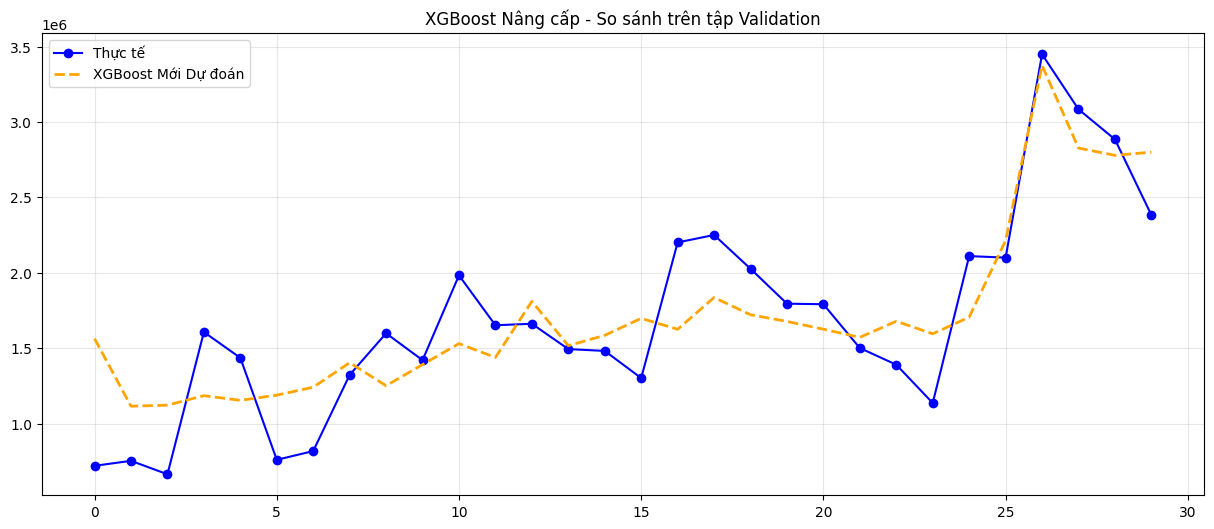

✅ File đã lưu: submission_xgb_v2.csv


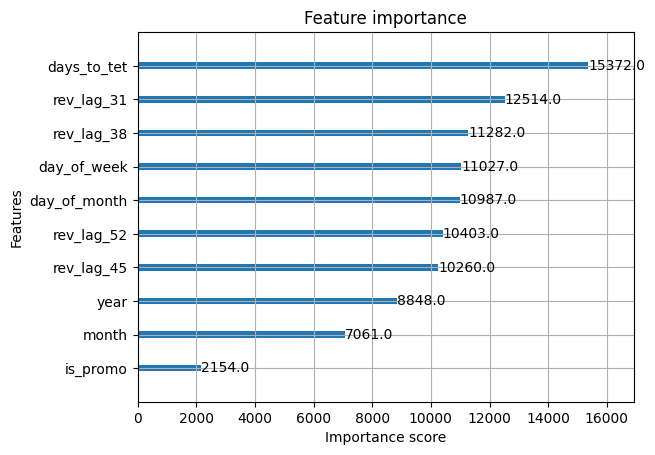

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor, plot_importance
from sklearn.metrics import mean_squared_error
import warnings

warnings.filterwarnings("ignore")

# ==========================================
# 1. ĐỌC DỮ LIỆU & GIỮ NGUYÊN FEATURE ENGINEERING
# ==========================================
DATA_DIR = "/kaggle/input/competitions/datathon-2026-round-1/"
sales = pd.read_csv(DATA_DIR + "sales.csv", parse_dates=["Date"])
test = pd.read_csv(DATA_DIR + "sample_submission.csv", parse_dates=["Date"])
promotions = pd.read_csv(DATA_DIR + "promotions.csv", parse_dates=["start_date", "end_date"])

avg_cogs_ratio = (sales['COGS'] / sales['Revenue']).mean()

train = sales.copy()
train["is_test"] = 0
test_df = test[["Date"]].copy()
test_df["is_test"] = 1
df = pd.concat([train, test_df], ignore_index=True).sort_values("Date")

# Features (Giữ nguyên bộ Lag "thần thánh")
df["day_of_week"] = df["Date"].dt.dayofweek
df["day_of_month"] = df["Date"].dt.day
df["month"] = df["Date"].dt.month
df["year"] = df["Date"].dt.year
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

# Tết & Promo
tet_dates = {2012:"2012-01-23", 2013:"2013-02-10", 2014:"2014-01-31", 2015:"2015-02-19",
             2016:"2016-02-08", 2017:"2017-01-28", 2018:"2018-02-16", 2019:"2019-02-05",
             2020:"2020-01-25", 2021:"2021-02-12", 2022:"2022-02-01", 2023:"2023-01-22",
             2024:"2024-02-10", 2025:"2025-01-29", 2026:"2026-02-17"}
df["tet_date"] = pd.to_datetime(df["year"].map(tet_dates))
df["days_to_tet"] = (df["tet_date"] - df["Date"]).dt.days
df["is_pre_tet"] = ((df["days_to_tet"] > 0) & (df["days_to_tet"] <= 21)).astype(int)

promo_range = pd.date_range(start=df["Date"].min(), end=df["Date"].max())
daily_p = pd.DataFrame({"Date": promo_range, "is_promo": 0})
for _, row in promotions.iterrows():
    daily_p.loc[(daily_p["Date"] >= row["start_date"]) & (daily_p["Date"] <= row["end_date"]), "is_promo"] = 1
df = df.merge(daily_p, on="Date", how="left").fillna(0)

# Lag Features (Duy trì bộ lag bắt chu kỳ tháng/tuần)
lags = [31, 38, 45, 52] 
for lag in lags:
    df[f"rev_lag_{lag}"] = df.groupby("is_test")["Revenue"].shift(lag)

features = ["day_of_week", "day_of_month", "month", "year", "is_weekend", 
            "days_to_tet", "is_pre_tet", "is_promo"] + [f"rev_lag_{l}" for l in lags]

train_final = df[df["is_test"] == 0].dropna(subset=features)
test_final = df[df["is_test"] == 1].fillna(0)

X_full = train_final[features]
y_full = train_final["Revenue"]

val_days = 30
X_train, X_val = X_full.iloc[:-val_days], X_full.iloc[-val_days:]
y_train, y_val = y_full.iloc[:-val_days], y_full.iloc[-val_days:]

# ==========================================
# 4. MODEL: NEW TUNED XGBOOST
# ==========================================
# Chúng ta sử dụng cấu hình mạnh hơn, thêm Regularization để tránh Overfit
new_xgb_params = {
    'n_estimators': 2000,
    'learning_rate': 0.01,         # Học chậm hơn nhưng kỹ hơn (CNN cũng dùng 0.001-0.01)
    'max_depth': 8,                # Tăng độ sâu để bắt kịp CNN ở các đỉnh cao
    'subsample': 0.8,
    'colsample_bytree': 0.7,
    'gamma': 0.1,                  # Thêm Gamma để cây "khó tính" hơn khi phân nhánh
    'reg_lambda': 1.5,             # L2 Regularization
    'reg_alpha': 0.5,              # L1 Regularization giúp loại bỏ nhiễu
    'random_state': 42,
    'objective': 'reg:squarederror',
    'early_stopping_rounds': 100
}

print("🚀 Đang huấn luyện XGBoost Phiên bản nâng cấp...")
model = XGBRegressor(**new_xgb_params)
model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=200)

# ==========================================
# 5. DỰ ĐOÁN VÀ SO SÁNH
# ==========================================
y_val_pred = model.predict(X_val)
y_test_pred = model.predict(test_final[features]).clip(0)

# Vẽ hình xem thử XGBoost mới "nhảy múa" thế nào
plt.figure(figsize=(15, 6))
plt.plot(y_val.values, label='Thực tế', marker='o', color='blue')
plt.plot(y_val_pred, label='XGBoost Mới Dự đoán', linestyle='--', color='orange', linewidth=2)
plt.title("XGBoost Nâng cấp - So sánh trên tập Validation")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Xuất file
submission = pd.DataFrame({
    "Date": test_final["Date"].dt.strftime('%Y-%m-%d'),
    "COGS": y_test_pred * avg_cogs_ratio,
    "Revenue": y_test_pred
})
submission.to_csv("submission_xgb_v2.csv", index=False)
print("✅ File đã lưu: submission_xgb_v2.csv")

# Xem Feature Importance
plot_importance(model, max_num_features=10)
plt.show()

🚀 Đang huấn luyện XGBoost Nâng cấp...
[0]	validation_0-rmse:2635644.69603
[200]	validation_0-rmse:534745.24752
[400]	validation_0-rmse:364848.83329
[600]	validation_0-rmse:355635.26302
[730]	validation_0-rmse:355995.29055

✅ HOÀN TẤT! File đã lưu: submission_final_v3.csv


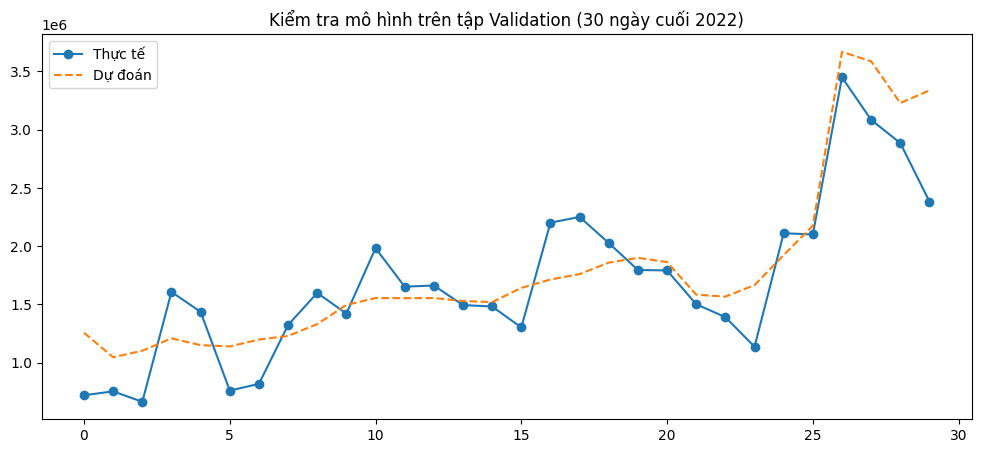

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import warnings

warnings.filterwarnings("ignore")

# ==========================================
# 1. ĐỌC DỮ LIỆU
# ==========================================
DATA_DIR = "/kaggle/input/competitions/datathon-2026-round-1/"
sales = pd.read_csv(DATA_DIR + "sales.csv", parse_dates=["Date"])
test = pd.read_csv(DATA_DIR + "sample_submission.csv", parse_dates=["Date"])
promotions = pd.read_csv(DATA_DIR + "promotions.csv", parse_dates=["start_date", "end_date"])

# Lưu tỉ lệ COGS trung bình
avg_cogs_ratio = (sales['COGS'] / sales['Revenue']).mean()

# Chuẩn bị dataframe tổng
df = pd.concat([sales[['Date', 'Revenue']], test[['Date']]], ignore_index=True)
df = df.sort_values("Date").reset_index(drop=True)

# ==========================================
# 2. FEATURE ENGINEERING (CHIẾN THUẬT DÀI HẠN)
# ==========================================
df['month'] = df['Date'].dt.month
df['day_of_week'] = df['Date'].dt.dayofweek
df['year'] = df['Date'].dt.year
df['day_of_month'] = df['Date'].dt.day
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

# i. Mã hóa vòng lặp (Cyclical Encoding) - Giúp model hiểu chu kỳ tháng/tuần
df['month_sin'] = np.sin(2 * np.pi * df['month']/12)
df['month_cos'] = np.cos(2 * np.pi * df['month']/12)
df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week']/7)
df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week']/7)

# ii. Logic Tết (2012 - 2026) - Cực quan trọng cho đỉnh doanh thu
tet_dates = {2012:"2012-01-23", 2013:"2013-02-10", 2014:"2014-01-31", 2015:"2015-02-19",
             2016:"2016-02-08", 2017:"2017-01-28", 2018:"2018-02-16", 2019:"2019-02-05",
             2020:"2020-01-25", 2021:"2021-02-12", 2022:"2022-02-01", 2023:"2023-01-22",
             2024:"2024-02-10", 2025:"2025-01-29", 2026:"2026-02-17"}
df['tet_date'] = pd.to_datetime(df['year'].map(tet_dates))
df['days_to_tet'] = (df['tet_date'] - df['Date']).dt.days
df['is_pre_tet'] = ((df['days_to_tet'] > 0) & (df['days_to_tet'] <= 21)).astype(int)

# iii. Đặc trưng Khuyến mãi (Xử lý khoảng trống 2023-2024)
# Đánh dấu những tháng thường xuyên có khuyến mãi lớn dựa trên lịch sử
promo_months = promotions['start_date'].dt.month.unique()
df['is_high_promo_month'] = df['month'].isin(promo_months).astype(int)

# iv. TRUNG BÌNH LỊCH SỬ (Target Encoding) - Thay thế cho Lag ngắn hạn
# Tính doanh thu trung bình của từng Thứ trong từng Tháng (dựa trên 10 năm dữ liệu)
historical_avg = df[df['Revenue'].notnull()].groupby(['month', 'day_of_week'])['Revenue'].mean().reset_index()
historical_avg.columns = ['month', 'day_of_week', 'avg_rev_month_dow']
df = df.merge(historical_avg, on=['month', 'day_of_week'], how='left')

# v. LAG NĂM (Dùng lag 364 ngày để tập Test luôn có dữ liệu)
df['rev_lag_364'] = df['Revenue'].shift(364)

# Chọn bộ Features tối ưu nhất
features = ['month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'is_weekend', 
            'day_of_month', 'is_pre_tet', 'days_to_tet', 'is_high_promo_month', 
            'avg_rev_month_dow', 'rev_lag_364', 'year']

# Tách Train/Test
train_final = df[df['Revenue'].notnull()].dropna(subset=['rev_lag_364'])
test_final = df[df['Revenue'].isnull()]

# ==========================================
# 3. TRAINING (XGBOOST TUNED)
# ==========================================
X = train_final[features]
y = train_final['Revenue']

# Tách Validation (30 ngày cuối của Train để đối chứng)
val_days = 30
X_train, X_val = X.iloc[:-val_days], X.iloc[-val_days:]
y_train, y_val = y.iloc[:-val_days], y.iloc[-val_days:]

model = XGBRegressor(
    n_estimators=2000,
    learning_rate=0.01,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=1,
    random_state=42,
    early_stopping_rounds=100
)

print("🚀 Đang huấn luyện XGBoost Nâng cấp...")
model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=200)

# ==========================================
# 4. DỰ ĐOÁN & XUẤT FILE
# ==========================================
y_test_pred = model.predict(test_final[features]).clip(0)

# Tạo file submission đúng định dạng mẫu
submission = pd.DataFrame({
    "Date": test_final["Date"].dt.strftime('%Y-%m-%d'),
    "COGS": y_test_pred * avg_cogs_ratio,
    "Revenue": y_test_pred
})

submission.to_csv("submission_final_v3.csv", index=False)
print("\n✅ HOÀN TẤT! File đã lưu: submission_final_v3.csv")

# Vẽ biểu đồ kiểm tra nhanh
plt.figure(figsize=(12, 5))
plt.plot(y_val.values, label='Thực tế', marker='o')
plt.plot(model.predict(X_val), label='Dự đoán', linestyle='--')
plt.title("Kiểm tra mô hình trên tập Validation (30 ngày cuối 2022)")
plt.legend()
plt.show()

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error
import warnings

warnings.filterwarnings("ignore")

# ==========================================
# 1. ĐỌC DỮ LIỆU
# ==========================================
DATA_DIR = "/kaggle/input/competitions/datathon-2026-round-1/"
sales = pd.read_csv(DATA_DIR + "sales.csv", parse_dates=["Date"])
test = pd.read_csv(DATA_DIR + "sample_submission.csv", parse_dates=["Date"])

avg_cogs_ratio = (sales['COGS'] / sales['Revenue']).mean()

df = pd.concat([sales[['Date', 'Revenue']], test[['Date']]], ignore_index=True)
df = df.sort_values("Date").reset_index(drop=True)

# ==========================================
# 2. FEATURE ENGINEERING "TOP 1"
# ==========================================
df['month'] = df['Date'].dt.month
df['day_of_week'] = df['Date'].dt.dayofweek
df['year'] = df['Date'].dt.year
df['day_of_year'] = df['Date'].dt.dayofyear
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

# Fourier Features (Bắt sóng chu kỳ cực chuẩn)
def add_fourier_features(df, period, n_harmonics):
    for i in range(1, n_harmonics + 1):
        df[f'fourier_sin_{period}_{i}'] = np.sin(2 * np.pi * i * df['day_of_year'] / period)
        df[f'fourier_cos_{period}_{i}'] = np.cos(2 * np.pi * i * df['day_of_year'] / period)
add_fourier_features(df, 365.25, 3) # Chu kỳ năm

# Tết Holidays (2012-2026)
tet_dates = {2012:"2012-01-23", 2013:"2013-02-10", 2014:"2014-01-31", 2015:"2015-02-19",
             2016:"2016-02-08", 2017:"2017-01-28", 2018:"2018-02-16", 2019:"2019-02-05",
             2020:"2020-01-25", 2021:"2021-02-12", 2022:"2022-02-01", 2023:"2023-01-22",
             2024:"2024-02-10", 2025:"2025-01-29", 2026:"2026-02-17"}
df['tet_date'] = pd.to_datetime(df['year'].map(tet_dates))
df['days_to_tet'] = (df['tet_date'] - df['Date']).dt.days
df['is_pre_tet'] = ((df['days_to_tet'] > 0) & (df['days_to_tet'] <= 21)).astype(int)

# Lag 364 & Rolling Stats (Mỏ neo quan trọng)
df['rev_lag_364'] = df['Revenue'].shift(364)
df['rev_rolling_mean_364_7'] = df['rev_lag_364'].rolling(window=7, center=True).mean()

# Target Encoding (Lịch sử 10 năm)
hist_avg = df[df['Revenue'].notnull()].groupby(['month', 'day_of_week'])['Revenue'].mean().reset_index()
hist_avg.columns = ['month', 'day_of_week', 'avg_historical']
df = df.merge(hist_avg, on=['month', 'day_of_week'], how='left')

# Drop NaN do tạo Lag
features = [col for col in df.columns if col not in ['Date', 'Revenue', 'tet_date']]
train_final = df[df['Revenue'].notnull()].dropna(subset=['rev_lag_364', 'rev_rolling_mean_364_7'])
test_final = df[df['Revenue'].isnull()].fillna(0)

# ==========================================
# 3. TRAINING VỚI LOG TRANSFORMATION
# ==========================================
X = train_final[features]
y = np.log1p(train_final['Revenue']) # Dùng Log để ổn định phương sai

X_train, X_val = X.iloc[:-60], X.iloc[-60:] # Val 60 ngày cho chắc chắn
y_train, y_val = y.iloc[:-60], y.iloc[-60:]

# Model 1: XGBoost
xgb = XGBRegressor(n_estimators=3000, learning_rate=0.005, max_depth=8, subsample=0.8, colsample_bytree=0.8,early_stopping_rounds=100, random_state=42, verbose=0)
xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)])

# Model 2: LightGBM
lgb = LGBMRegressor(n_estimators=3000, learning_rate=0.005, max_depth=8, subsample=0.8, colsample_bytree=0.8,early_stopping_rounds=100, random_state=42,verbose=0)
lgb.fit(X_train, y_train, eval_set=[(X_val, y_val)])

# ==========================================
# 4. ENSEMBLE (50/50) & INVERSE LOG
# ==========================================
pred_xgb = xgb.predict(test_final[features])
pred_lgb = lgb.predict(test_final[features])

# Kết hợp kết quả (Average Ensemble)
final_log_preds = (pred_xgb * 0.5) + (pred_lgb * 0.5)
final_preds = np.expm1(final_log_preds) # Chuyển ngược từ Log về Revenue

# ==========================================
# 5. XUẤT FILE
# ==========================================
submission = pd.DataFrame({
    "Date": test_final["Date"].dt.strftime('%Y-%m-%d'),
    "COGS": final_preds * avg_cogs_ratio,
    "Revenue": final_preds
})

submission.to_csv("submission_top1_hunt.csv", index=False)
print("✅ Đã tạo file 'submission_top1_hunt.csv'. Hy vọng sẽ phá mốc 632k!")

[0]	validation_0-rmse:0.89592
[1]	validation_0-rmse:0.89180
[2]	validation_0-rmse:0.88751
[3]	validation_0-rmse:0.88442
[4]	validation_0-rmse:0.88028
[5]	validation_0-rmse:0.87602
[6]	validation_0-rmse:0.87150
[7]	validation_0-rmse:0.86877
[8]	validation_0-rmse:0.86609
[9]	validation_0-rmse:0.86242
[10]	validation_0-rmse:0.85858
[11]	validation_0-rmse:0.85481
[12]	validation_0-rmse:0.85092
[13]	validation_0-rmse:0.84756
[14]	validation_0-rmse:0.84349
[15]	validation_0-rmse:0.84102
[16]	validation_0-rmse:0.83671
[17]	validation_0-rmse:0.83265
[18]	validation_0-rmse:0.82886
[19]	validation_0-rmse:0.82478
[20]	validation_0-rmse:0.82078
[21]	validation_0-rmse:0.81720
[22]	validation_0-rmse:0.81363
[23]	validation_0-rmse:0.80971
[24]	validation_0-rmse:0.80577
[25]	validation_0-rmse:0.80254
[26]	validation_0-rmse:0.79943
[27]	validation_0-rmse:0.79671
[28]	validation_0-rmse:0.79299
[29]	validation_0-rmse:0.79106
[30]	validation_0-rmse:0.78752
[31]	validation_0-rmse:0.78535
[32]	validation_0-

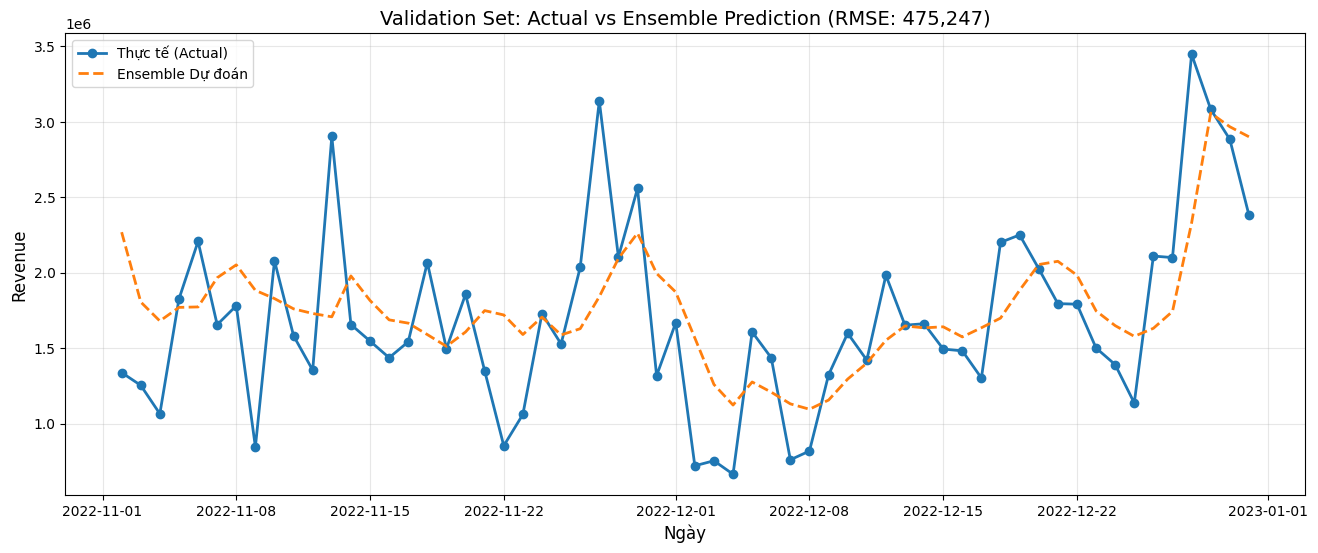

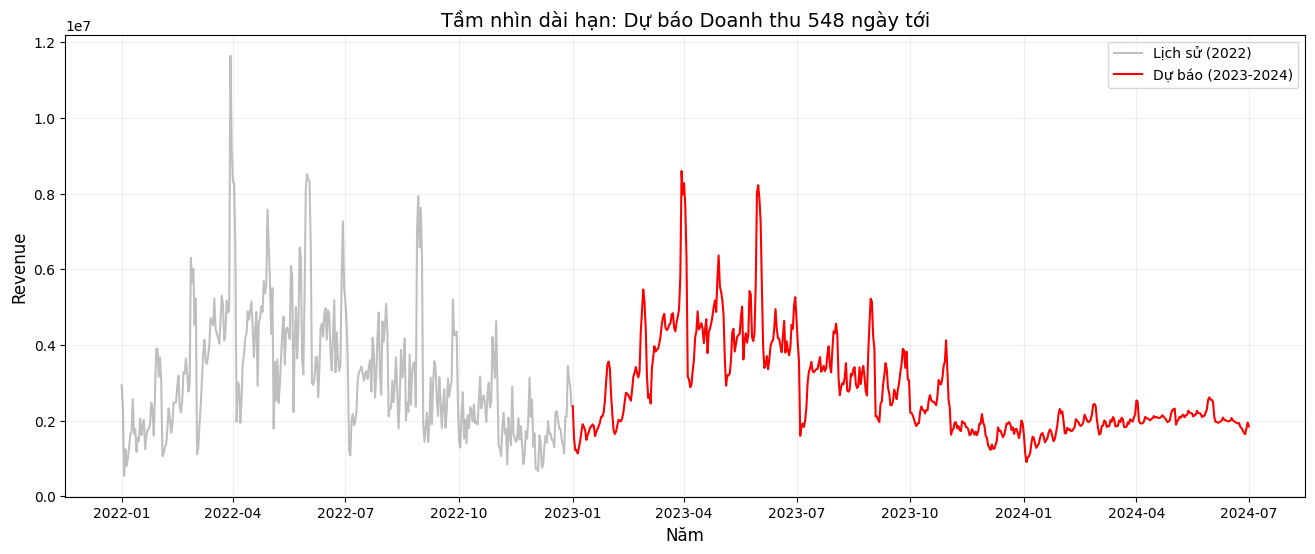

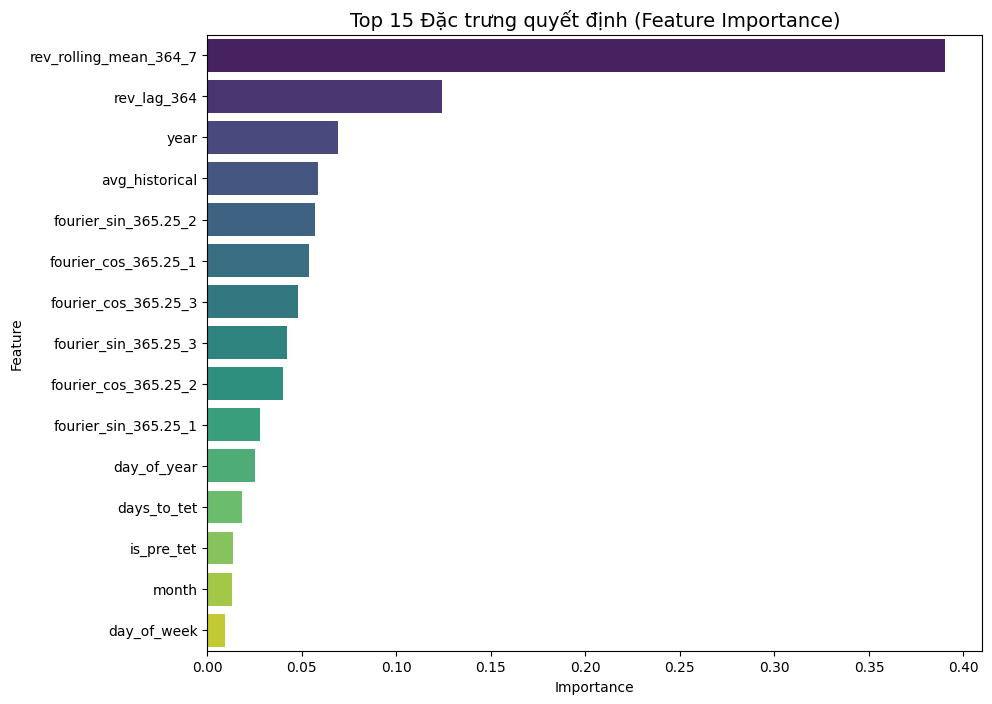

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. BIỂU ĐỒ SO SÁNH TRÊN TẬP VALIDATION (60 NGÀY CUỐI 2022)
# ==========================================
# Nghịch đảo Log để về giá trị Revenue thực tế
y_val_real = np.expm1(y_val)
y_val_pred_ensemble = np.expm1((xgb.predict(X_val) * 0.5) + (lgb.predict(X_val) * 0.5))

plt.figure(figsize=(16, 6))
plt.plot(train_final.iloc[-60:]['Date'], y_val_real, label='Thực tế (Actual)', marker='o', color='#1f77b4', linewidth=2)
plt.plot(train_final.iloc[-60:]['Date'], y_val_pred_ensemble, label='Ensemble Dự đoán', linestyle='--', color='#ff7f0e', linewidth=2)

# Tính RMSE cho tập Validation
rmse_val = np.sqrt(mean_squared_error(y_val_real, y_val_pred_ensemble))
plt.title(f"Validation Set: Actual vs Ensemble Prediction (RMSE: {rmse_val:,.0f})", fontsize=14)
plt.xlabel("Ngày", fontsize=12)
plt.ylabel("Revenue", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('val_comparison.png')

# ==========================================
# 2. BIỂU ĐỒ DỰ BÁO TƯƠNG LAI (548 NGÀY - 2023 ĐẾN 2024)
# ==========================================
plt.figure(figsize=(16, 6))
# Vẽ dữ liệu quá khứ (lấy 1 năm gần nhất để dễ nhìn)
past_data = sales[sales['Date'] >= '2022-01-01']
plt.plot(past_data['Date'], past_data['Revenue'], label='Lịch sử (2022)', color='gray', alpha=0.5)

# Vẽ dữ liệu dự báo
plt.plot(test_final['Date'], final_preds, label='Dự báo (2023-2024)', color='red', linewidth=1.5)

plt.title("Tầm nhìn dài hạn: Dự báo Doanh thu 548 ngày tới", fontsize=14)
plt.xlabel("Năm", fontsize=12)
plt.ylabel("Revenue", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.2)
plt.savefig('long_term_forecast.png')

# ==========================================
# 3. BIỂU ĐỒ ĐỘ QUAN TRỌNG CỦA ĐẶC TRƯNG (FEATURE IMPORTANCE)
# ==========================================
plt.figure(figsize=(10, 8))
# Lấy độ quan trọng từ XGBoost (đại diện)
imp_df = pd.DataFrame({'Feature': features, 'Importance': xgb.feature_importances_})
imp_df = imp_df.sort_values(by='Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=imp_df.head(15), palette='viridis')
plt.title("Top 15 Đặc trưng quyết định (Feature Importance)", fontsize=14)
plt.savefig('feature_importance.png')

plt.show()